# Parallel Analysis


In [ ]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from ANALYSIS_HW_HD_utils import *
from ANALYSIS_plots_utils import *
from ANALYSIS_create_npy_file import create_npy_file
from reset_folder_notebook import reset_folder

no_instructions = 5000


In [7]:
parallel_registers = ["r0", "r1", "r2", "r3", "r4", "r5", "r6", "r7", "r8", "r9", "r10", "r11", "r12", "sp", "lr"]
parallel_trace_dir = "output_decapsulation_parallel_TRIM"
result_dir = "Results_decapsulation_parallel"
no_instructions = 500
reset_folder(result_dir)

reset_result_dir = False
if reset_result_dir:
    reset_folder(result_dir)
os.makedirs(result_dir, exist_ok=True)

create_npy_file(f"{result_dir}/RESULTS_HW", parallel_trace_dir, "HW", parallel_registers)
create_npy_file(f"{result_dir}/RESULTS_HD", parallel_trace_dir, "HD", parallel_registers)


Creating simulation traces model.... HW
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted
The last trace that was captured is Trace 641
Finished creating Results_decapsulation_parallel/RESULTS_HW.npy, shape = (641, 29237)
Creating simulation traces model.... HD
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted
The last trace that was captured is Trace 641
Finished creating Results_decapsulation_parallel/RESULTS_HD.npy, shape = (641, 29236)


In [8]:
filename_hw = f"{result_dir}/RESULTS_HW.npy"
filename_hd = f"{result_dir}/RESULTS_HD.npy"

data_HW = np.load(filename_hw)
data_HD = np.load(filename_hd)

information(data_HW)
information(data_HD)


The shape of the data is: (641, 29237)
The type of the data is: float64
The first 2 traces are: [[ 77.  79.  80. ... 156. 146. 144.]
 [ 77.  79.  80. ... 155. 145. 143.]]
If there are any NaN values: False
The shape of the data is: (641, 29236)
The type of the data is: float64
The first 2 traces are: [[ 2.  1.  9. ...  0. 28.  2.]
 [ 2.  1.  9. ...  0. 28.  2.]]
If there are any NaN values: False


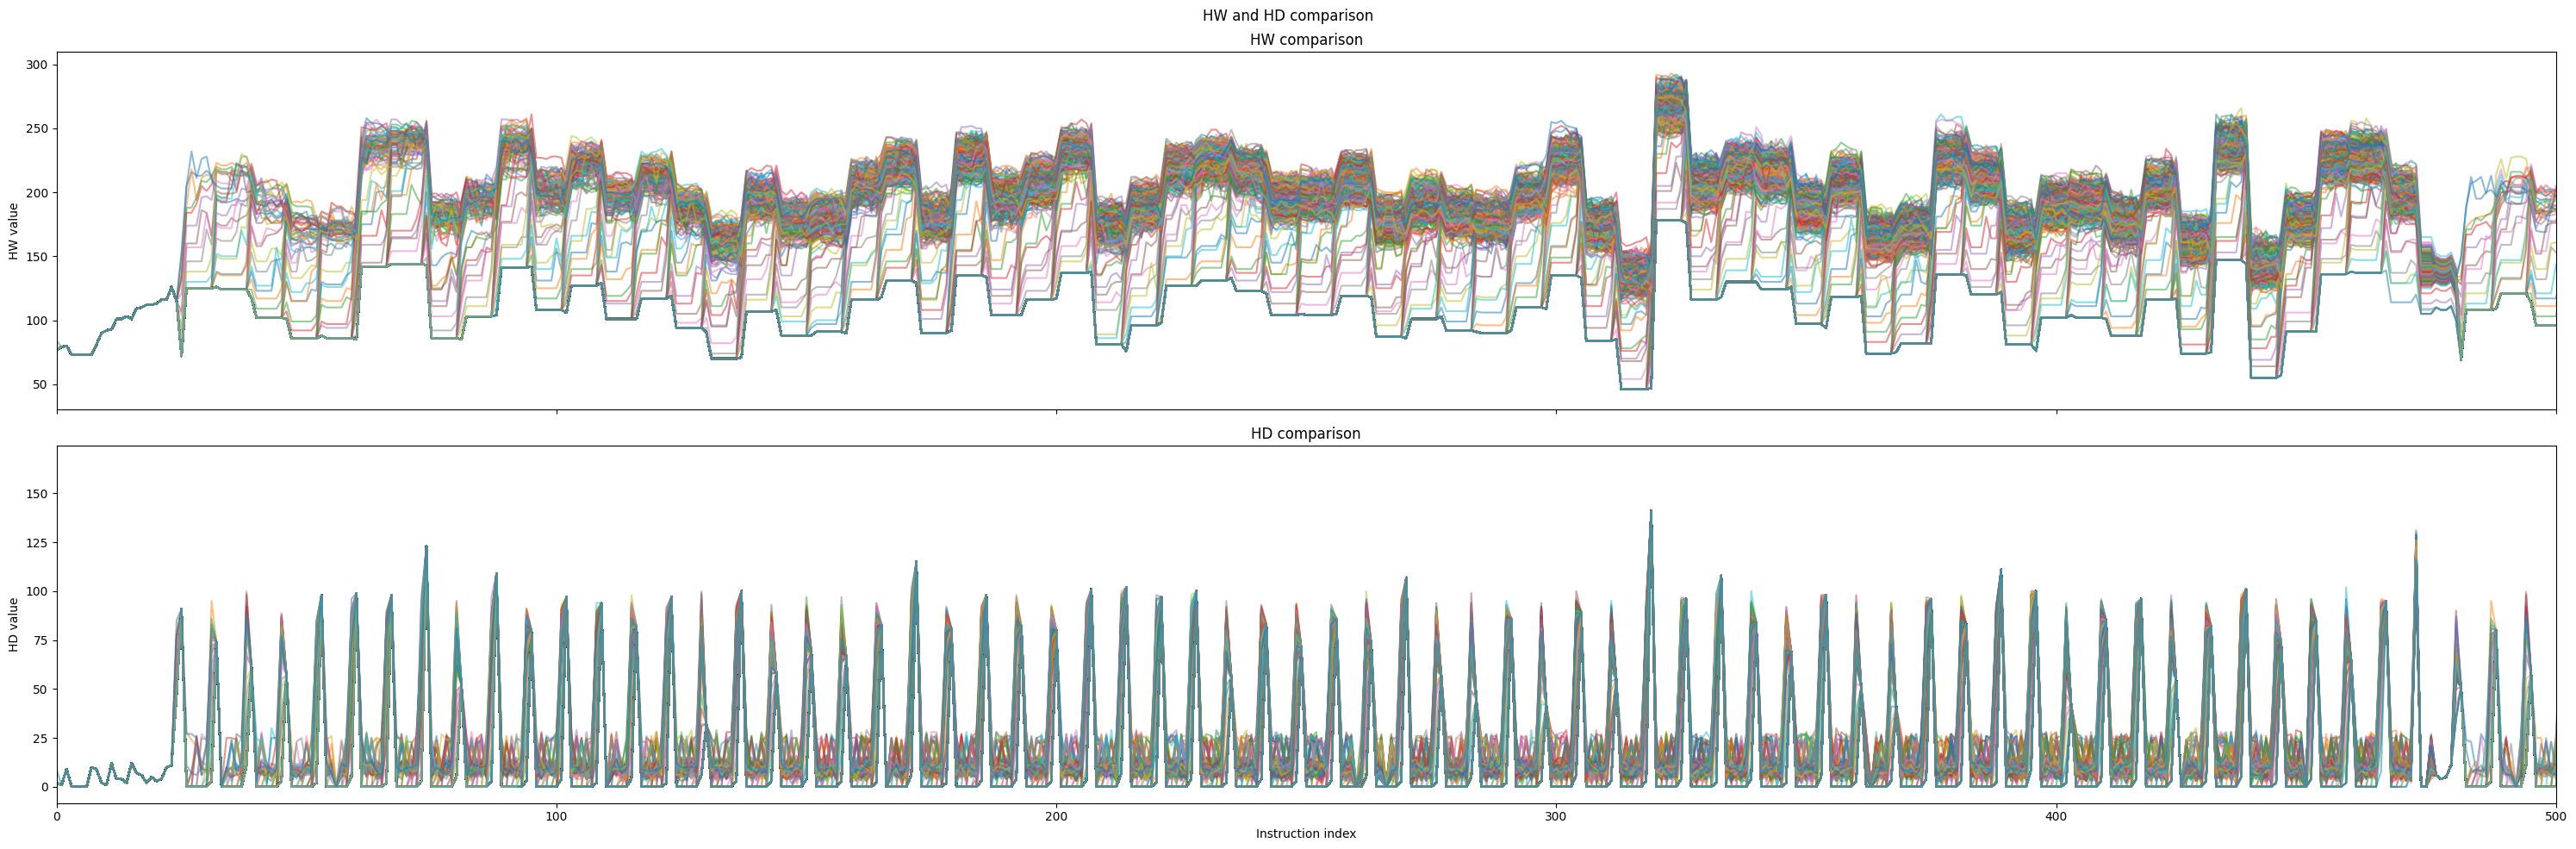

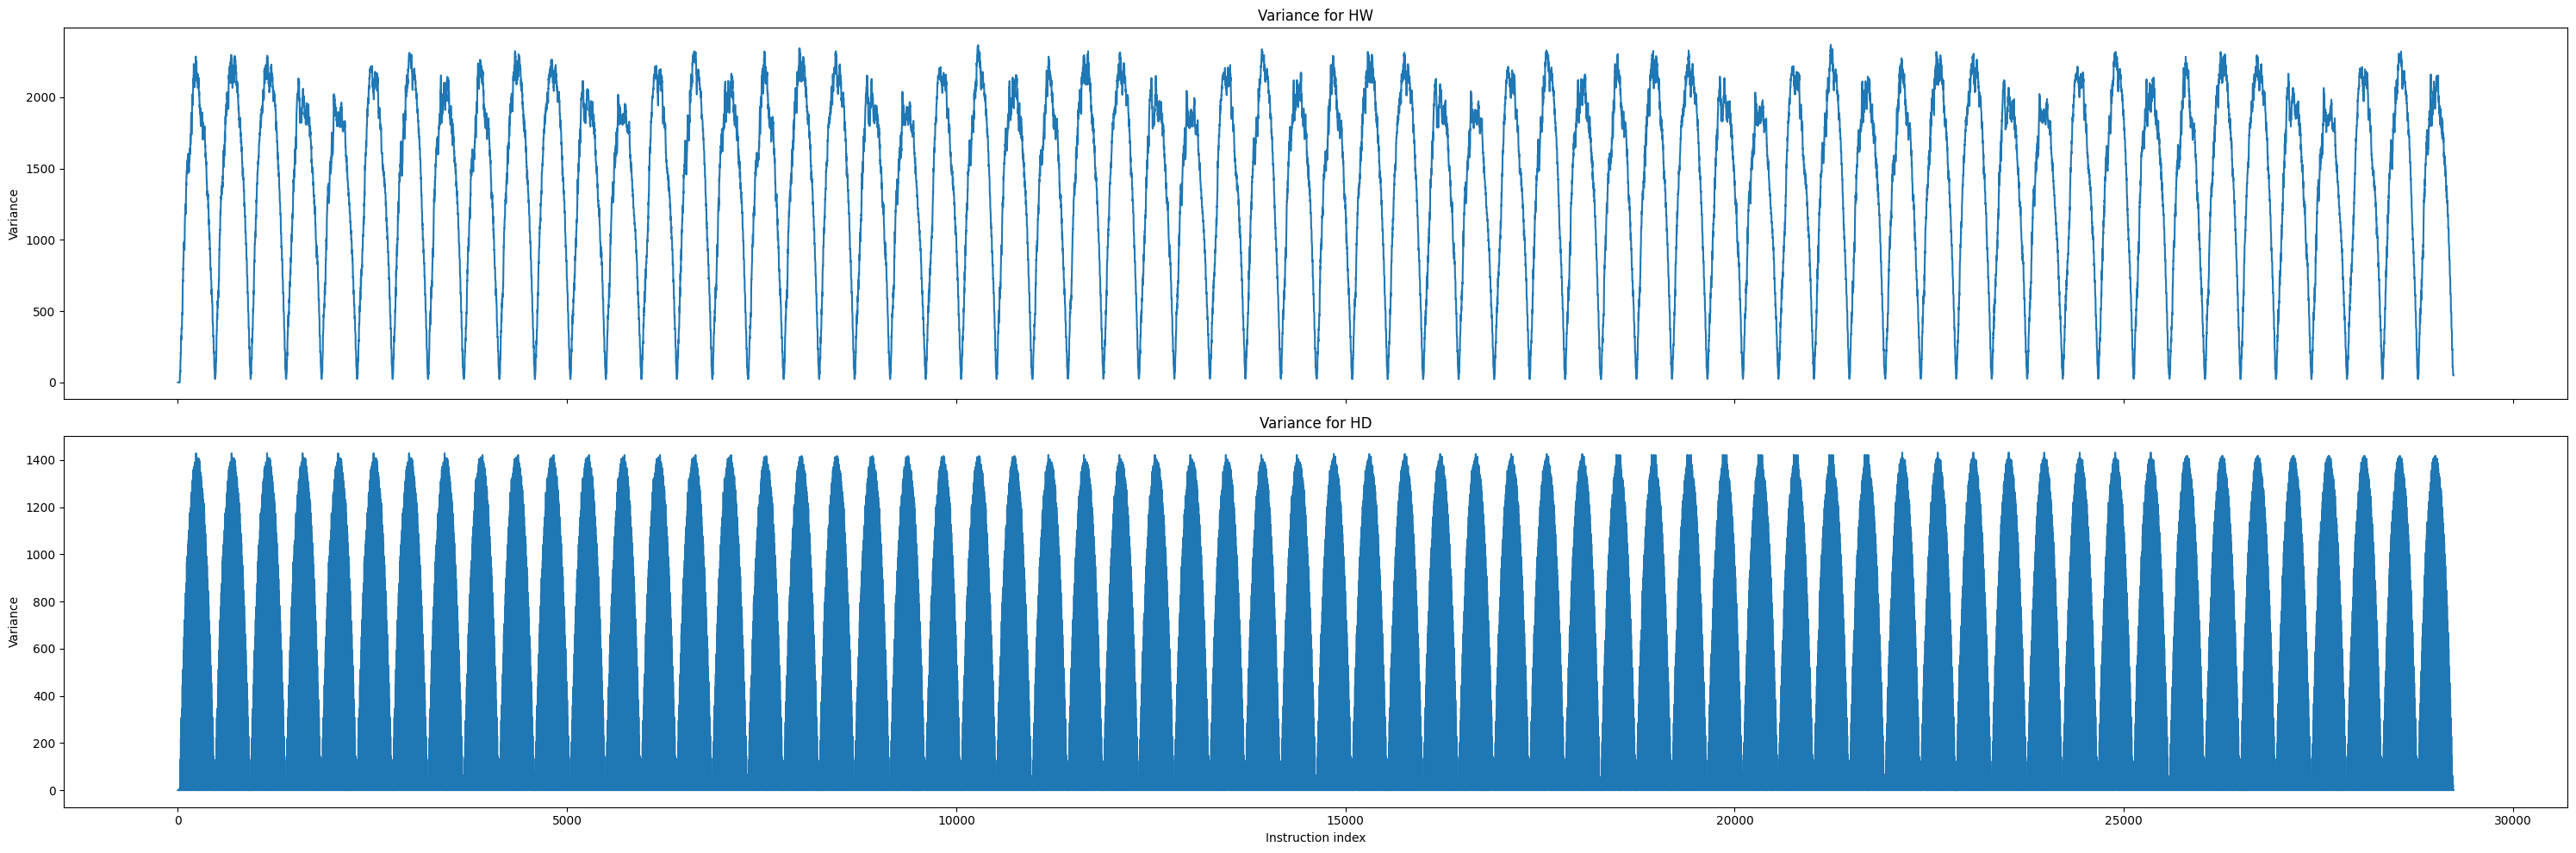

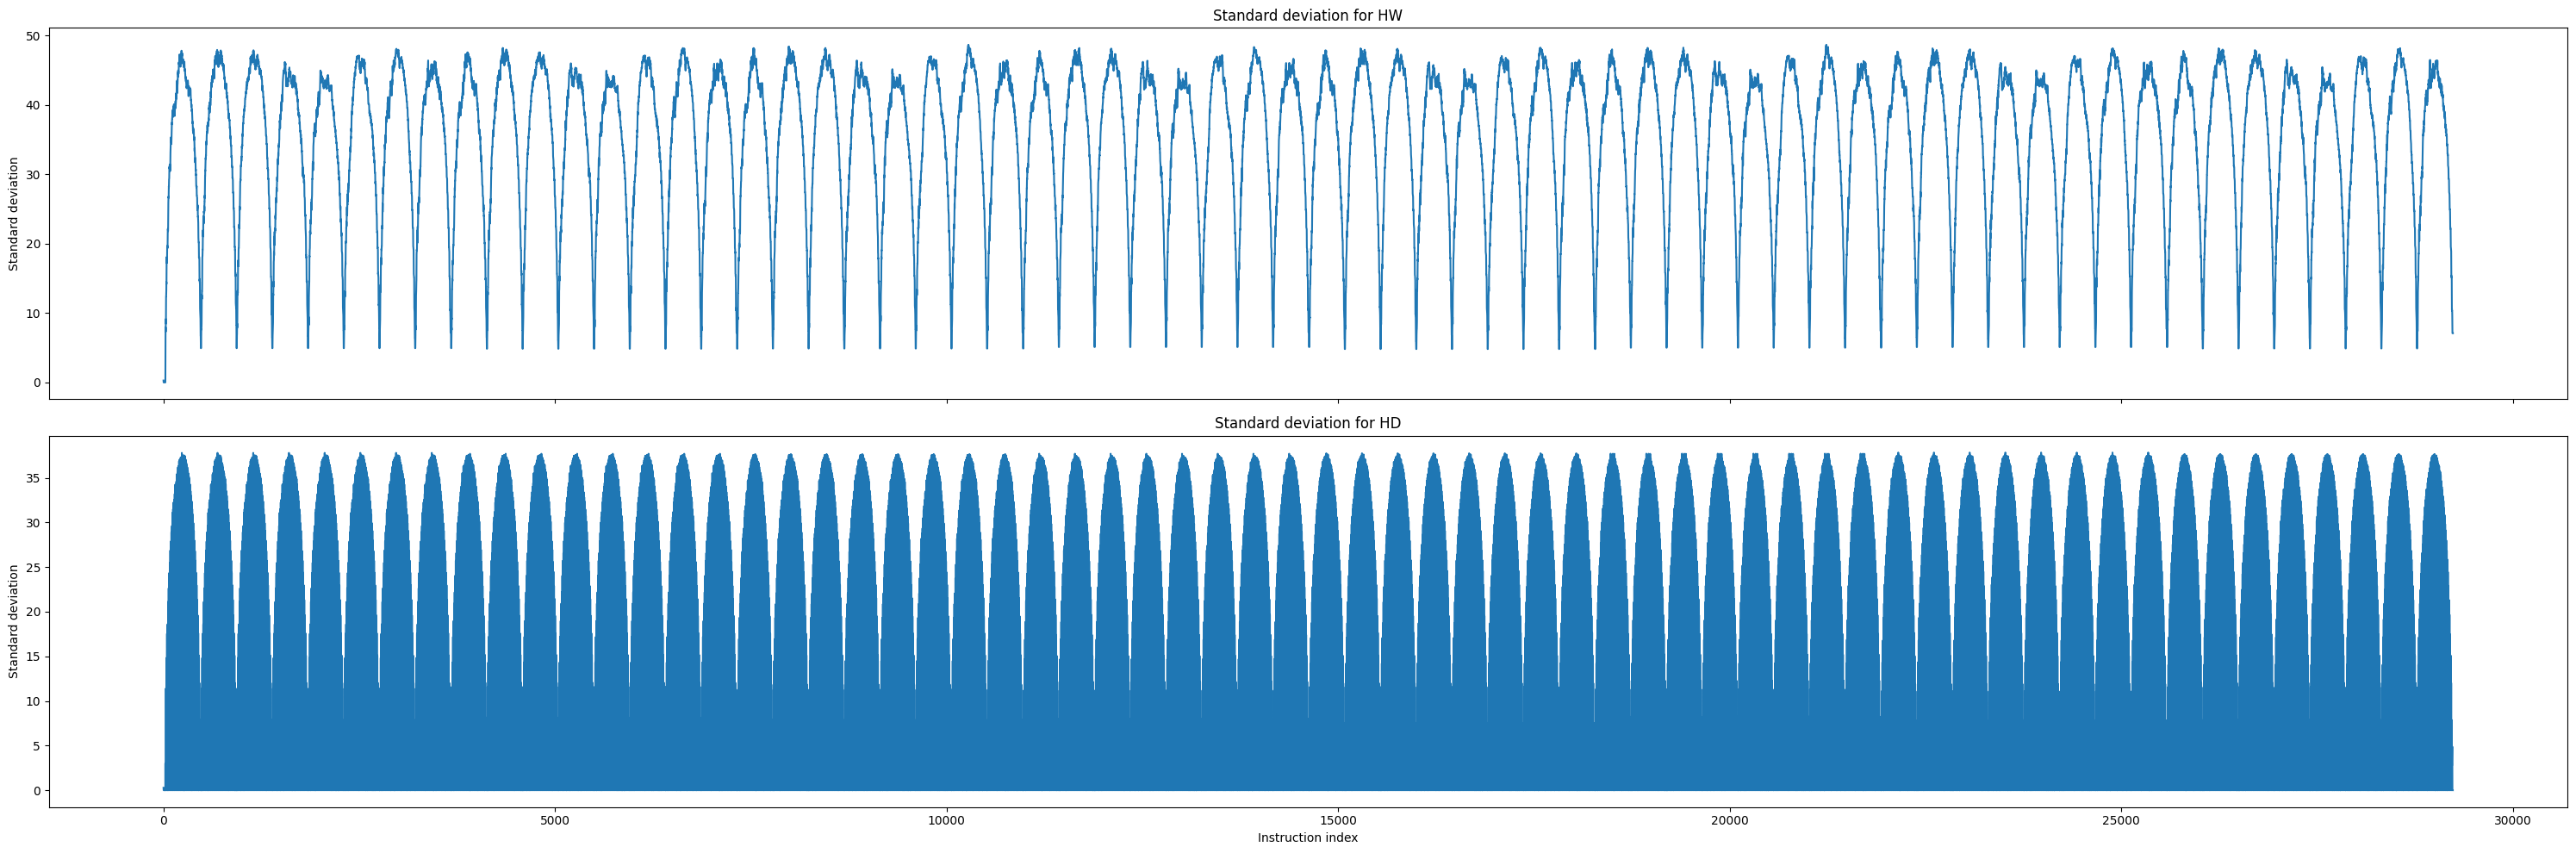

In [9]:
plot_hw_hd_comparison(data_HW, data_HD, save_path=os.path.join(result_dir, "traces_plot.png"), no_instructions=no_instructions)
plot_variance_and_std(data_HW, data_HD, result_dir, no_instructions=no_instructions)


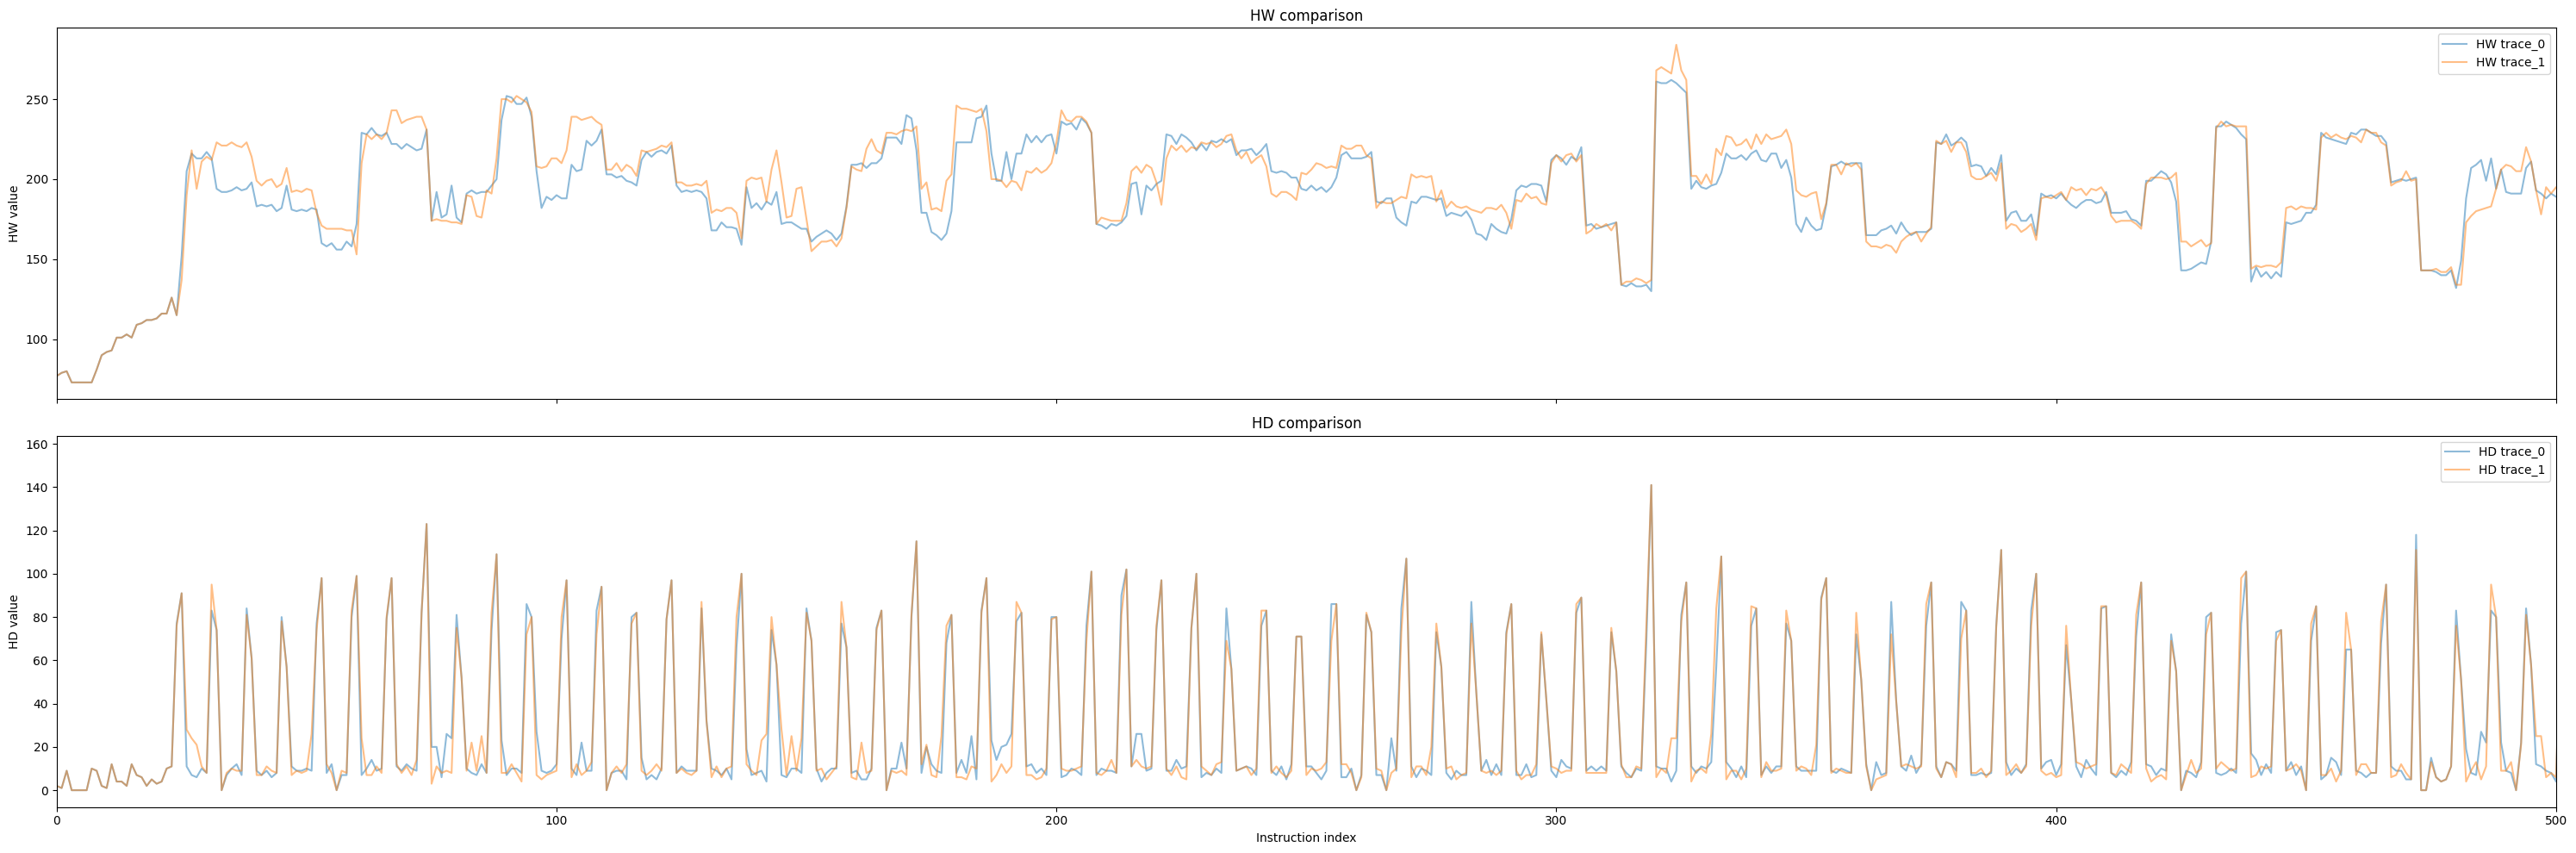

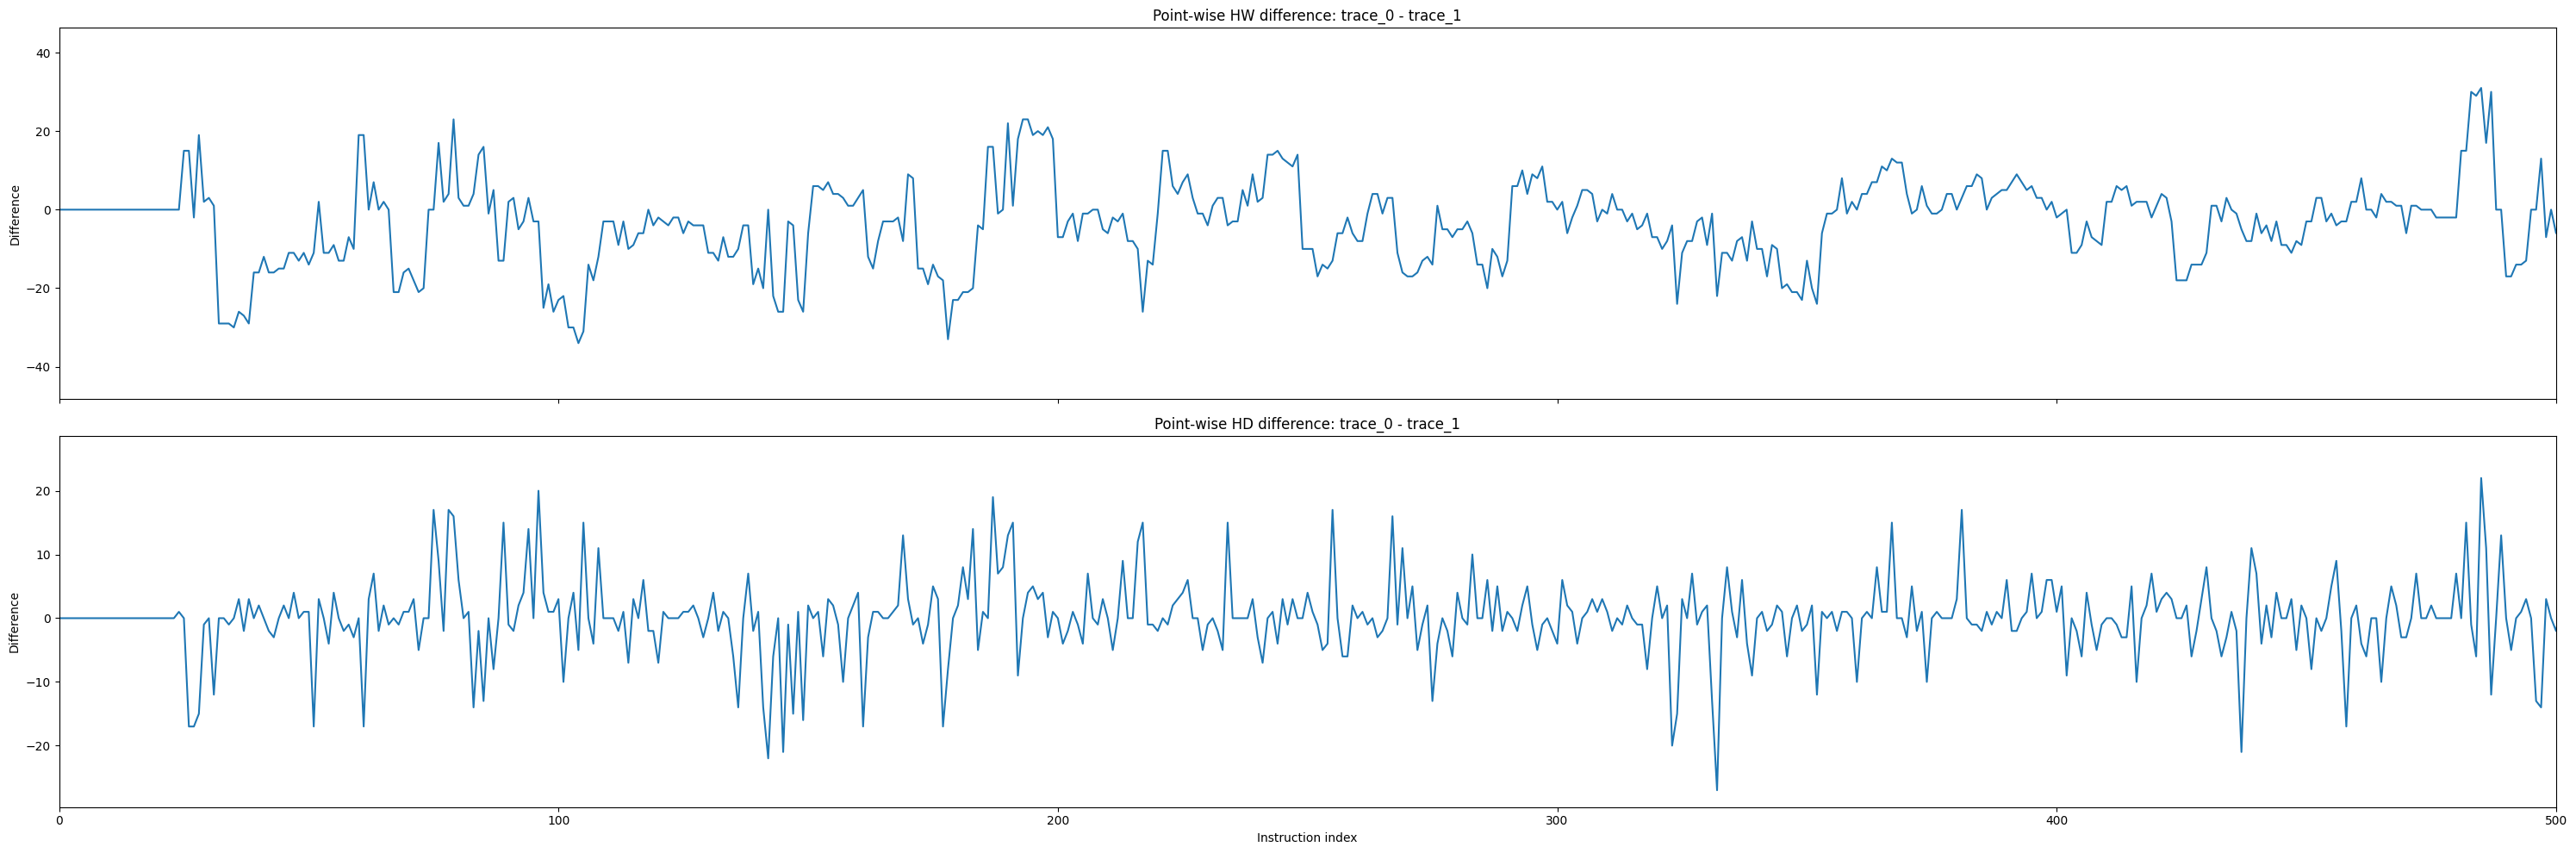

Correlation HW (0,1) = 0.9091
Correlation HW (0,128) = 0.4247
Correlation HW (0,256) = 0.3859
Correlation HW (0,480) = 0.4517
Correlation HW (0,620) = 0.5990
Correlation HD (0,1) = 0.9878
Correlation HD (0,128) = 0.8793
Correlation HD (0,256) = 0.8288
Correlation HD (0,480) = 0.7546
Correlation HD (0,620) = 0.9460


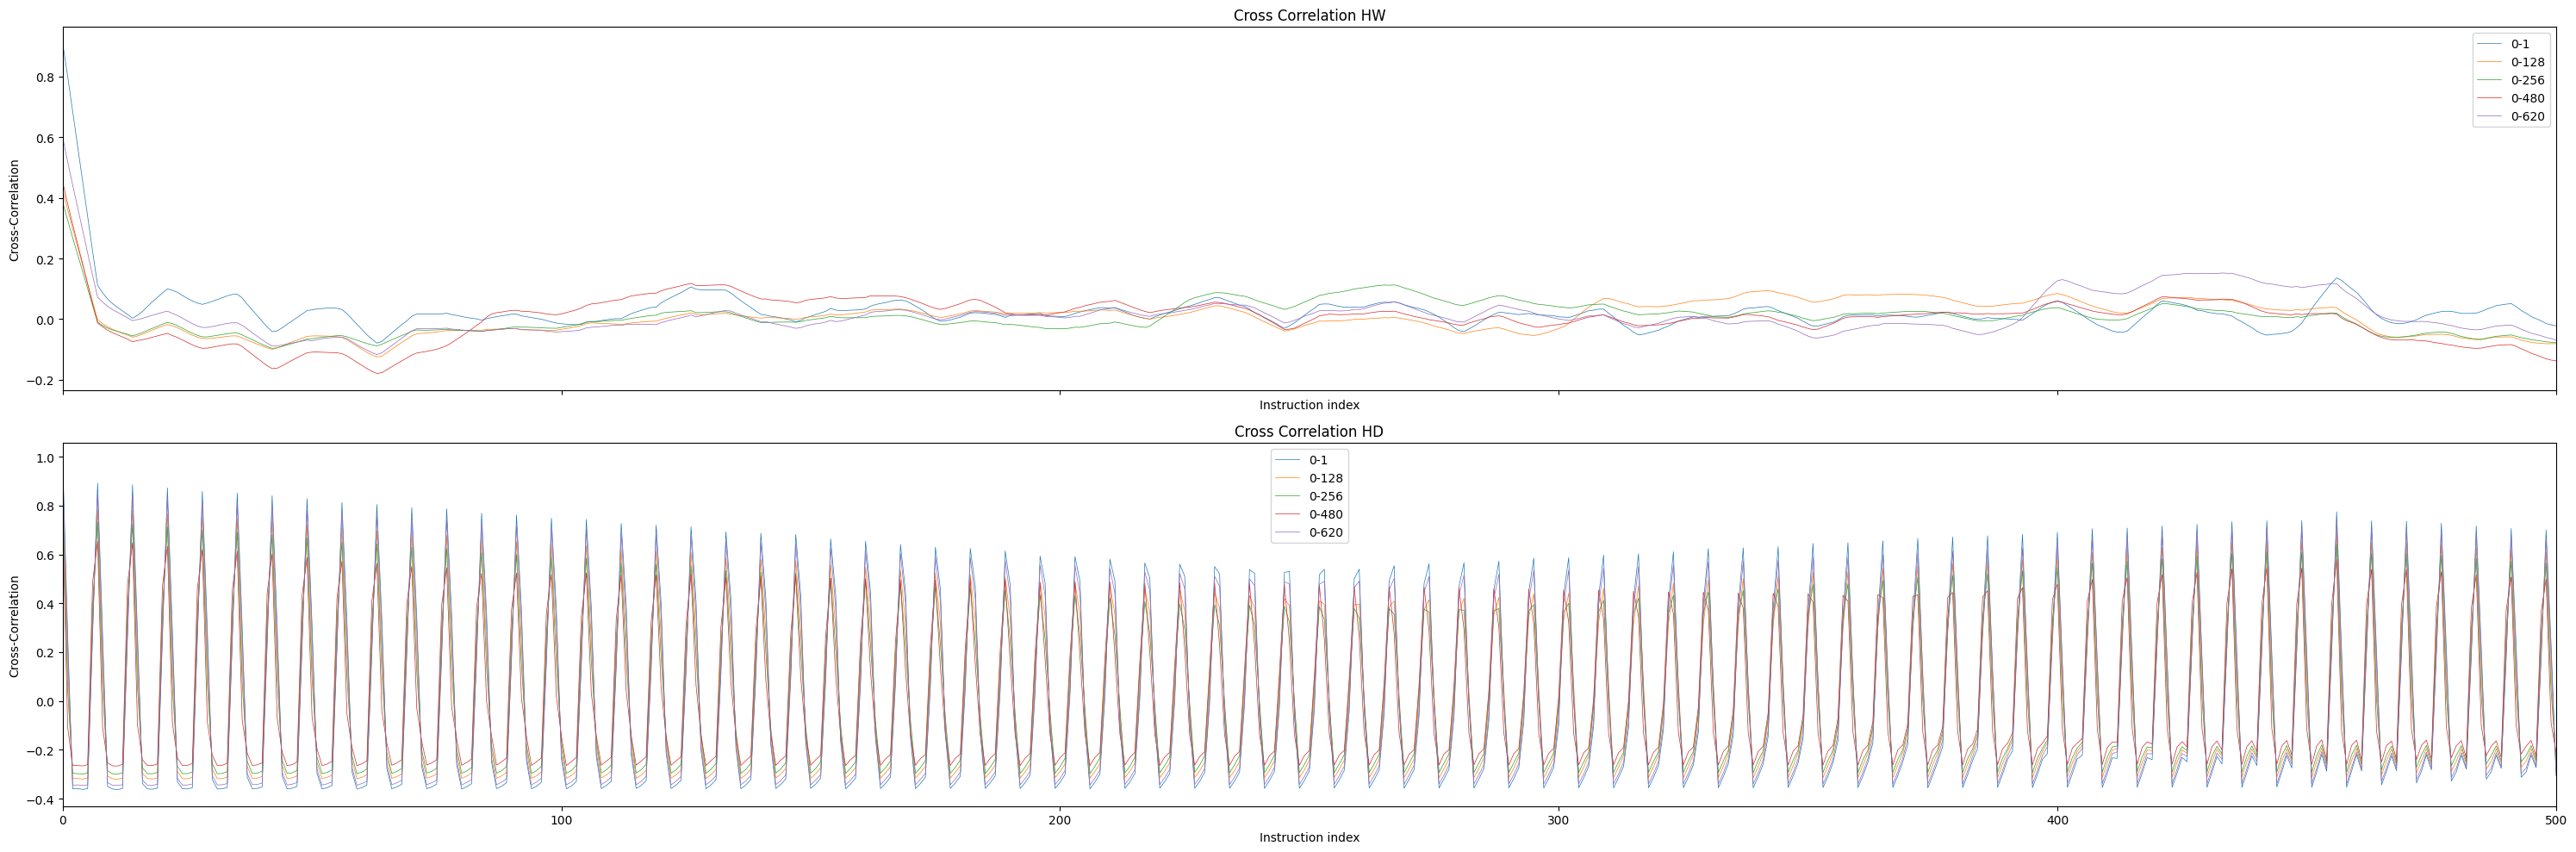

In [10]:
index1 = 0
index2 = 1
pairs = [(0, 1), (0, 128), (0, 256), (0, 480), (0, 620)]
plot_hw_hd_two_traces(data_HW, data_HD, index1, index2, save_path=os.path.join(result_dir, "hw_and_hd_traces_comparison.png"), no_instructions=no_instructions)
plot_hw_hd_difference(data_HW, data_HD, index1, index2, save_path=os.path.join(result_dir, "pointwise_difference.png"), no_instructions=no_instructions)
plot_cross_correlation_hw_hd(data_HW, data_HD, pairs, save_path=os.path.join(result_dir, "correlation_between_pairs.png"), no_instructions=no_instructions)
